In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
from matplotlib import cm


INPUT_ROOT = Path("/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda")

SR_ORIGINAL = 50000
SR_TARGET = 16000

MIC_COLUMN_INDEX = 7
WINDOW = 1.0
OVERLAP = 0.5

#csv_files = sorted(csv_path.rglob("*.csv"))
csv_files = list(INPUT_ROOT.rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

# Show the first few files
for path in csv_files[:5]:
    print(path)


Number of CSV files found: 1951
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/55.7056.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/40.3456.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/14.336.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/29.4912.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/44.6464.csv


In [3]:
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found under {INPUT_ROOT}")

sample_path = csv_files[0]
sample_df = pd.read_csv(sample_path, header=None)

print("Sample file:", sample_path)
print("Shape:", sample_df.shape)
print("Number of columns:", sample_df.shape[1])

if sample_df.shape[1] <= MIC_COLUMN_INDEX:
    raise ValueError(
        f"Expected at least {MIC_COLUMN_INDEX + 1} columns, "
        f"but this file has only {sample_df.shape[1]} columns. "
        "Check the CSV separator, for example sep=';' or sep='\\t'."
    )

print("\nFirst 5 values from the selected 8th column:")
display(sample_df.iloc[:5, MIC_COLUMN_INDEX])


Sample file: /home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/55.7056.csv
Shape: (250000, 8)
Number of columns: 8

First 5 values from the selected 8th column:


0   -0.163260
1    0.047972
2   -0.116110
3   -0.027671
4   -0.029934
Name: 7, dtype: float64

A window is a short segment cut from the audio signal. we are splitting each audio signal into wondows of 1 second. 

`SR_ORIGINAL=50000`, one second of audio contains 50000 samples. 

each window is 50000 values (of the csv column).

the windows overlap by 50% (0.5).

Ex: 
Window 1: 0.0s to 1.0s
Window 2: 0.5s to 1.5s
Window 3: 1.0s to 2.0s
Window 4: 1.5s to 2.5s




In [4]:
def load_mic(csv_path, mic_column_index=MIC_COLUMN_INDEX):
    """Load only the microphone/audio column from one CSV file."""
    df = pd.read_csv(csv_path, header=None)

    if df.shape[1] <= mic_column_index:
        raise ValueError(
            f"{csv_path} has {df.shape[1]} columns, "
            f"but column index {mic_column_index} was requested. "
            "Check whether the CSV separator is correct."
        )

    # Select only the 8th column when mic_column_index = 7
    audio = df.iloc[:, mic_column_index].to_numpy(dtype=np.float32)

    # Remove DC offset
    audio = audio - np.mean(audio)

    # Normalize to approximately [-1, 1]
    audio = audio / (np.max(np.abs(audio)) + 1e-8)

    return audio


def split_windows(signal, sr, window_seconds=1.0, overlap=0.5):
    """Split a 1D signal into overlapping windows."""
    window_size = int(sr * window_seconds)
    step = int(window_size * (1 - overlap))

    if step <= 0:
        raise ValueError("overlap must be less than 1.0")

    windows = []

    for start in range(0, len(signal) - window_size + 1, step):
        windows.append(signal[start:start + window_size])

    return windows


def make_logmel_tinyml(audio_window):
    """Convert one audio window into a log-mel spectrogram."""
    audio_window = librosa.resample(
        audio_window,
        orig_sr=SR_ORIGINAL,
        target_sr=SR_TARGET
    )

    mel = librosa.feature.melspectrogram(
        y=audio_window,
        sr=SR_TARGET,
        n_fft=512,
        hop_length=160,
        n_mels=40
    )

    logmel = librosa.power_to_db(mel, ref=np.max)

    return logmel.astype(np.float32)


X - many log-mel spectrograms extracted from the 8th column of all CSV files


In [5]:
X = [] #input data (audio features)
y = [] # label for each item in X
file_paths = []

for csv_path in csv_files:
    # Label = first folder after INPUT_ROOT
    label = csv_path.relative_to(INPUT_ROOT).parts[0]

    audio = load_mic(csv_path)
    windows = split_windows(
        audio,
        sr=SR_ORIGINAL,
        window_seconds=WINDOW,
        overlap=OVERLAP
    )

    for window in windows:
        logmel = make_logmel_tinyml(window)

        X.append(logmel)
        y.append(label)
        file_paths.append(str(csv_path))

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of file paths:", len(file_paths))
print("Labels:", sorted(set(y)))


X shape: (17559, 40, 101)
y shape: (17559,)
Number of file paths: 17559
Labels: [np.str_('horizontal-misalignment'), np.str_('imbalance'), np.str_('normal'), np.str_('overhang'), np.str_('underhang'), np.str_('vertical-misalignment')]


17559 windows/examples
40 mel-frequency bands
101 time frames

horizontal-misalignment    1773
imbalance                  2997
normal                      441
overhang                   4617
underhang                  5022
vertical-misalignment      2709
Name: count, dtype: int64

<Axes: title={'center': 'Number of windows per label'}>

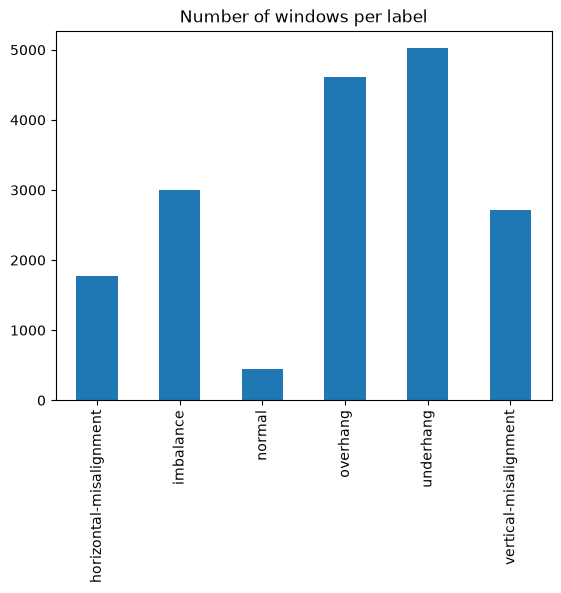

In [6]:
# how many audio windows were created for each class/label.
label_counts = pd.Series(y).value_counts().sort_index()
display(label_counts)

label_counts.plot(kind="bar", title="Number of windows per label")


1773 log-mel examples from horizontal-misalignment
2997 log-mel examples from imbalance
441 log-mel examples from normal
4617 log-mel examples from overhang
5022 log-mel examples from underhang
2709 log-mel examples from vertical-misalignment

In [7]:
labels_sorted = sorted(set(y))
label_to_id = {label: idx for idx, label in enumerate(labels_sorted)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

y_encoded = np.array([label_to_id[label] for label in y], dtype=np.int64)

print("Label to ID mapping:")
for label, idx in label_to_id.items():
    print(f"{idx}: {label}")

print("y_encoded shape:", y_encoded.shape)


Label to ID mapping:
0: horizontal-misalignment
1: imbalance
2: normal
3: overhang
4: underhang
5: vertical-misalignment
y_encoded shape: (17559,)


In [8]:
OUTPUT_PATH = INPUT_ROOT.parent / "mafaulda_logmel_features.npz"

np.savez_compressed(
    OUTPUT_PATH,
    X=X,
    y=y,
    y_encoded=y_encoded,
    file_paths=np.array(file_paths),
    labels=np.array(labels_sorted)
)

print("Saved to:", OUTPUT_PATH)

Saved to: /home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda_logmel_features.npz


In [24]:
y_binary = np.array([0 if label == "normal" else 1 for label in y], dtype=np.int64)

binary_label_names = np.array(["normal", "faulty"])

print("X shape:", X.shape)
print("y_binary shape:", y_binary.shape)

print(pd.Series(y_binary).map({0: "normal", 1: "faulty"}).value_counts())

X shape: (17559, 40, 101)
y_binary shape: (17559,)
faulty    17118
normal      441
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

file_paths_array = np.array(file_paths)

# One row per window
df_split = pd.DataFrame({
    "file_path": file_paths_array,
    "label": y_encoded
})

# One row per original CSV file
file_level = df_split.groupby("file_path")["label"].first().reset_index()

train_files, test_files = train_test_split(
    file_level["file_path"],
    test_size=0.20,
    random_state=42,
    stratify=file_level["label"]
)

train_file_level = file_level[file_level["file_path"].isin(train_files)]

train_files, val_files = train_test_split(
    train_file_level["file_path"],
    test_size=0.20,
    random_state=42,
    stratify=train_file_level["label"]
)

train_mask = np.isin(file_paths_array, train_files)
val_mask = np.isin(file_paths_array, val_files)
test_mask = np.isin(file_paths_array, test_files)

X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_val = X[val_mask]
y_val = y_encoded[val_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

print("Training set:", X_train.shape, pd.Series(y_train).value_counts().to_dict())
print("Valitation set:", X_val.shape, pd.Series(y_val).value_counts().to_dict())
print("Test set:", X_test.shape, pd.Series(y_test).value_counts().to_dict())

Training set: (11232, 40, 101) {4: 3213, 3: 2952, 1: 1917, 5: 1737, 0: 1134, 2: 279}
Valitation set: (2808, 40, 101) {4: 801, 3: 738, 1: 477, 5: 432, 0: 288, 2: 72}
Test set: (3519, 40, 101) {4: 1008, 3: 927, 1: 603, 5: 540, 0: 351, 2: 90}


In [26]:
# normalization

mean = X_train.mean()
std = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [27]:
X_train = X_train[..., np.newaxis].astype(np.float32)
X_val = X_val[..., np.newaxis].astype(np.float32)
X_test = X_test[..., np.newaxis].astype(np.float32)

print("CNN input shape:", X_train.shape)

CNN input shape: (11232, 40, 101, 1)


In [28]:
# classe normal é menor que as outras, entao
from sklearn.utils.class_weight import compute_class_weight

num_classes = len(labels_sorted)
classes = np.arange(num_classes)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)


class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_values)
}

print("Class weights:")
for class_id, weight in class_weight.items():
    print(class_id, labels_sorted[class_id], weight)

Class weights:
0 horizontal-misalignment 1.6507936507936507
1 imbalance 0.9765258215962441
2 normal 6.709677419354839
3 overhang 0.6341463414634146
4 underhang 0.5826330532212886
5 vertical-misalignment 1.077720207253886


In [14]:
import sys
print(sys.executable)
print(sys.version)

import tensorflow as tf
print(tf.__version__)

/home/aicha/Documents/UFSC/tcc/preprocessing/venv/bin/python
3.12.8 (main, May  3 2026, 22:13:28) [GCC 15.2.0]


I0000 00:00:1782953971.451787  867962 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782953971.453999  867962 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782953971.717340  867962 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782953973.687012  867962 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

2.21.0


In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]
num_classes = len(labels_sorted)

def build_lightweight_multiclass_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 2
    x = layers.DepthwiseConv2D(
        kernel_size=(3, 3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters=16,
        kernel_size=(1, 1),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 3
    x = layers.DepthwiseConv2D(
        kernel_size=(3, 3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters=24,
        kernel_size=(1, 1),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Lightweight classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


model = build_lightweight_multiclass_cnn(input_shape, num_classes)

try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
except:
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 101, 8)     │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 101, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 40, 101, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 50, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 20, 50, 8)      │            72 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 50, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 20, 50, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 50, 16)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 20, 50, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 20, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_3              │ (None, 10, 25, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 10, 25, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 10, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 25, 24)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 25, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 10, 25, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           40

 Total params: 1,590 (6.21 KB)

 Trainable params: 1,446 (5.65 KB)

 Non-trainable params: 144 (576.00 B)

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.2085 - loss: 1.7485 - val_accuracy: 0.1026 - val_loss: 1.8041 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2778 - loss: 1.6216 - val_accuracy: 0.1026 - val_loss: 1.8289 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3492 - loss: 1.4923 - val_accuracy: 0.1863 - val_loss: 1.7952 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.4298 - loss: 1.3634 - val_accuracy: 0.3896 - val_loss: 1.5146 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5067 - loss: 1.2408 - val_accuracy: 0.2714 - val_loss: 1.5635 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5540 - loss: 1.1253 - val_accuracy: 0.3743 - val_loss: 1.4604 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5899 - loss: 1.0434 - val_acc

In [31]:
test_results = model.evaluate(X_test, y_test, verbose=0)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

loss: 0.5134
compile_metrics: 0.7843


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.7843137254901961
Balanced accuracy: 0.7923610624550705
                         precision    recall  f1-score   support

horizontal-misalignment       0.74      0.82      0.78       351
              imbalance       0.69      0.51      0.59       603
                 normal       0.28      0.87      0.42        90
               overhang       0.84      0.86      0.85       927
              underhang       0.85      0.79      0.82      1008
  vertical-misalignment       0.96      0.90      0.93       540

               accuracy                           0.78      3519
              macro avg       0.73      0.79      0.73      3519
           weighted avg       0.81      0.78      0.79      3519



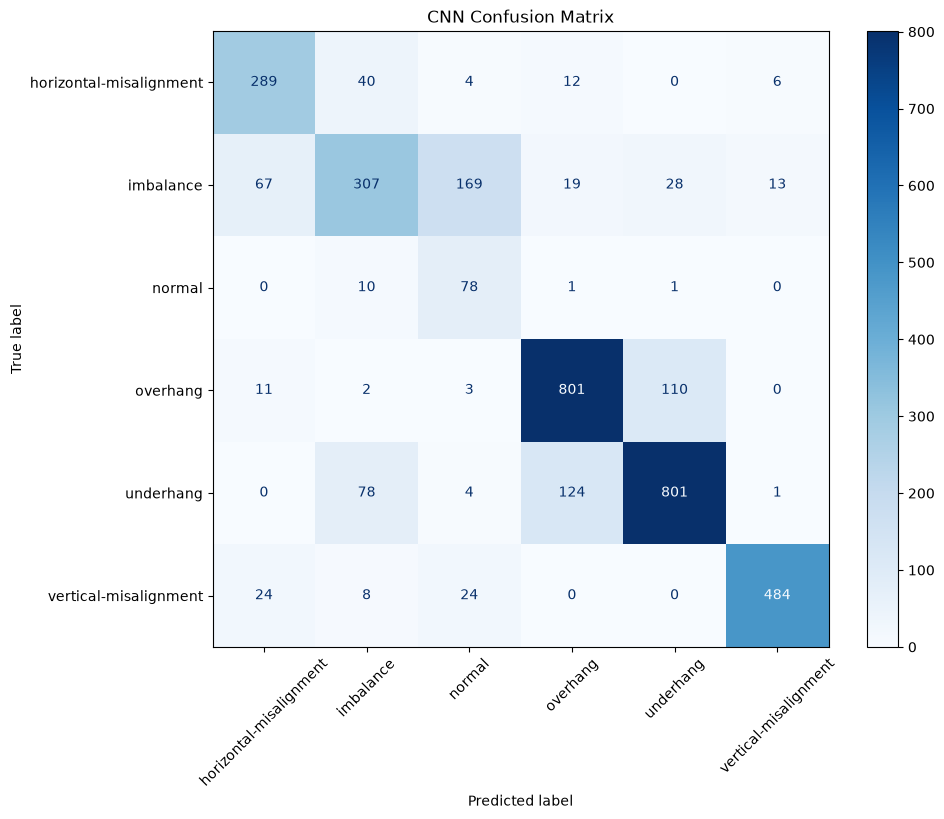

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print("Accuracy:", np.mean(y_pred == y_test))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=labels_sorted
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_sorted
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
model.save("engine_fault_light_cnn.keras")

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("engine_fault_light_cnn_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("Float32 TFLite model size:", len(tflite_model) / 1024, "KB")

INFO:tensorflow:Assets written to: /tmp/tmphc44al0z/assets


INFO:tensorflow:Assets written to: /tmp/tmphc44al0z/assets


Saved artifact at '/tmp/tmphc44al0z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 101, 1), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137755712591568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712591952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712587920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712590608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712590416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712593

W0000 00:00:1782962699.358493  867962 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782962699.358659  867962 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782962699.359347  867962 reader.cc:83] Reading SavedModel from: /tmp/tmphc44al0z
I0000 00:00:1782962699.359889  867962 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782962699.359893  867962 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmphc44al0z
I0000 00:00:1782962699.366231  867962 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782962699.411751  867962 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmphc44al0z
I0000 00:00:1782962699.423494  867962 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 64153 microseconds.


In [35]:
def representative_dataset():
    n_samples = min(100, len(X_train))
    indices = np.random.choice(len(X_train), size=n_samples, replace=False)

    for idx in indices:
        sample = X_train[idx:idx+1].astype(np.float32)
        yield [sample]


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()

with open("binary_engine_fault_light_cnn_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("Int8 TFLite model size:", len(tflite_int8_model) / 1024, "KB")

INFO:tensorflow:Assets written to: /tmp/tmph0tv6p9x/assets


INFO:tensorflow:Assets written to: /tmp/tmph0tv6p9x/assets


Saved artifact at '/tmp/tmph0tv6p9x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 101, 1), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137755712591568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712591952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712587920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712590608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712592144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712590416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137755712593

/home/aicha/Documents/UFSC/tcc/preprocessing/venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782962704.696899  867962 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782962704.696913  867962 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Int8 TFLite model size: 11.1875 KB


I0000 00:00:1782962704.697005  867962 reader.cc:83] Reading SavedModel from: /tmp/tmph0tv6p9x
I0000 00:00:1782962704.697687  867962 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782962704.697692  867962 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmph0tv6p9x
I0000 00:00:1782962704.704741  867962 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782962704.743691  867962 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmph0tv6p9x
I0000 00:00:1782962704.754227  867962 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 57229 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1782962704.932511  867962 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [36]:
interpreter = tf.lite.Interpreter(model_path="binary_engine_fault_light_cnn_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

Input details: [{'name': 'serving_default_keras_tensor_23:0', 'index': 0, 'shape': array([  1,  40, 101,   1], dtype=int32), 'shape_signature': array([ -1,  40, 101,   1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.032054316252470016, 57), 'quantization_parameters': {'scales': array([0.03205432], dtype=float32), 'zero_points': array([57], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 26, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


/home/aicha/Documents/UFSC/tcc/preprocessing/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [38]:
def predict_tflite_int8(sample):
    # sample shape: (1, n_mels, n_frames, 1), float32 normalized
    input_scale, input_zero_point = input_details[0]["quantization"]

    sample_int8 = sample / input_scale + input_zero_point
    sample_int8 = np.clip(sample_int8, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], sample_int8)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    output_scale, output_zero_point = output_details[0]["quantization"]
    output_float = (output.astype(np.float32) - output_zero_point) * output_scale

    return output_float.ravel()[0]


sample = X_test[0:1]
prob_faulty = predict_tflite_int8(sample)

print("Probability faulty:", prob_faulty)
print("Predicted class:", "faulty" if prob_faulty >= 0.5 else "normal")
print("True class:", "faulty" if y_test[0] == 1 else "normal")

Probability faulty: 0.0078125
Predicted class: normal
True class: normal
